In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [22]:
df = pd.read_csv(r"D:\SMART COACH\dataset\passenger_detail.csv")

print(df.head())

   id  passenger_name  age       gender  train_no booking_type       source  \
0   1    Nert Spitell   54       Female     84471       Direct        Salem   
1   2   Lelah Manston   76  Genderfluid     75255       Tatkal   Coimbatore   
2   3  Lodovico Dicke   36         Male     88415      Counter  Tirunelveli   
3   4  Ruperta Talloe   16       Female     96439       Online      Chennai   
4   5  Daveen Wakeley   37  Genderfluid     80648       Direct  Tirunelveli   

  destination coach  seat_no  fare travel_date ticket_status  
0     Madurai    A2       53   224   1/17/2026     Confirmed  
1     Chennai    B1       41  2102    9/1/2018       Waiting  
2       Salem    S1       29  2117   3/26/2025           RAC  
3      Trichy    A1       52  1932   3/10/2019       Waiting  
4      Trichy    D1       24   713   7/25/2020     Cancelled  


In [23]:
print(df.isnull().sum())

id                0
passenger_name    0
age               0
gender            0
train_no          0
booking_type      0
source            0
destination       0
coach             0
seat_no           0
fare              0
travel_date       0
ticket_status     0
dtype: int64


In [24]:
encoder = LabelEncoder()

cols = [
    'gender',
    'booking_type',
    'ticket_status'
]

for col in cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   id  passenger_name  age  gender  train_no  booking_type       source  \
0   1    Nert Spitell   54       2     84471             1        Salem   
1   2   Lelah Manston   76       3     75255             3   Coimbatore   
2   3  Lodovico Dicke   36       5     88415             0  Tirunelveli   
3   4  Ruperta Talloe   16       2     96439             2      Chennai   
4   5  Daveen Wakeley   37       3     80648             1  Tirunelveli   

  destination coach  seat_no  fare travel_date  ticket_status  
0     Madurai    A2       53   224   1/17/2026              1  
1     Chennai    B1       41  2102    9/1/2018              3  
2       Salem    S1       29  2117   3/26/2025              2  
3      Trichy    A1       52  1932   3/10/2019              3  
4      Trichy    D1       24   713   7/25/2020              0  


## Single Linear Regression

In [25]:
X = df[['age']]
y = df['fare']

In [26]:
model = LinearRegression()
model.fit(X, y)
print("Model Trained")

Model Trained


In [29]:
prediction = model.predict(
    pd.DataFrame([[25]], columns=['age'])
)
print("Predicted Fare:", prediction[0])

Predicted Fare: 1335.6524319218058


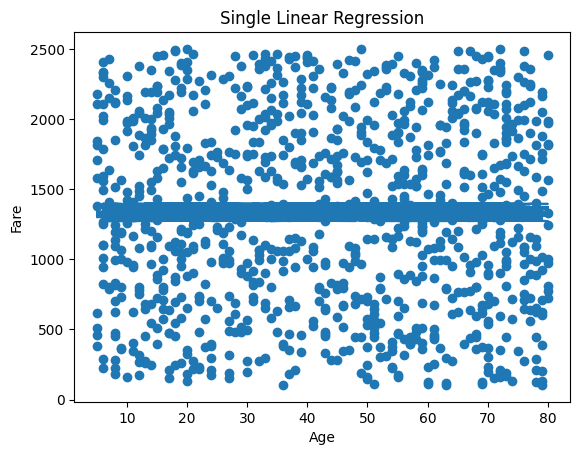

In [20]:
plt.scatter(df['age'], df['fare'])
plt.plot(df['age'], model.predict(X))
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Single Linear Regression")
plt.show()

## Multi Linear Regression

In [33]:
X = df[[
    'age',
    'gender',
    'booking_type',
    'ticket_status'
]]

y = df['fare']

In [34]:
model = LinearRegression()
model.fit(X, y)
print("Multiple Regression Model Trained")

Multiple Regression Model Trained


In [35]:
prediction = model.predict(
    pd.DataFrame([[
        25,
        1,
        2,
        1
    ]],
    columns=[
        'age',
        'gender',
        'booking_type',
        'ticket_status'
    ])
)

print("Predicted Fare:", prediction[0])

Predicted Fare: 1352.1825985667351


In [36]:
score = model.score(X, y)
print("Model Accuracy:", score)

Model Accuracy: 0.00259066315721157
